# Cohort Retention Analysis

## Objective

This analysis groups customers by their first purchase month and tracks their purchasing activity over subsequent months.

The goal is to understand whether customers continue purchasing after acquisition and identify differences in retention across customer cohorts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "/content/cleaned_sales.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

print(df.shape)
print(df["CustomerID"].nunique())

/tmp/ipykernel_2548/3603670872.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(1029609, 16)
5878


In [4]:
cohort_df = df[
    df["CustomerID"].notna()
].copy()

cohort_df["CustomerID"] = (
    cohort_df["CustomerID"]
    .astype(float)
    .astype(int)
    .astype(str)
)

In [5]:
cohort_df["InvoiceMonth"] = (
    cohort_df["InvoiceDate"]
    .dt.to_period("M")
)

In [6]:
cohort_df[
    ["CustomerID", "InvoiceDate", "InvoiceMonth"]
].head()

,CustomerID,InvoiceDate,InvoiceMonth
0,13085,2009-12-01 07:45:00,2009-12
1,13085,2009-12-01 07:45:00,2009-12
2,13085,2009-12-01 07:45:00,2009-12
3,13085,2009-12-01 07:45:00,2009-12
4,13085,2009-12-01 07:45:00,2009-12


In [7]:
first_purchase = (
    cohort_df
    .groupby("CustomerID")["InvoiceMonth"]
    .min()
)

In [9]:
cohort_df["CohortMonth"] = (
    cohort_df["CustomerID"]
    .map(first_purchase)
)
cohort_df[
    [
        "CustomerID",
        "InvoiceMonth",
        "CohortMonth"
    ]
].head(20)

,CustomerID,InvoiceMonth,CohortMonth
0,13085,2009-12,2009-12
1,13085,2009-12,2009-12
2,13085,2009-12,2009-12
3,13085,2009-12,2009-12
4,13085,2009-12,2009-12
5,13085,2009-12,2009-12
6,13085,2009-12,2009-12
7,13085,2009-12,2009-12
8,13085,2009-12,2009-12
9,13085,2009-12,2009-12


In [10]:
cohort_df["CohortIndex"] = (
    (
        cohort_df["InvoiceMonth"].dt.year
        - cohort_df["CohortMonth"].dt.year
    ) * 12
    +
    (
        cohort_df["InvoiceMonth"].dt.month
        - cohort_df["CohortMonth"].dt.month
    )
)

In [11]:
cohort_df[
    [
        "CustomerID",
        "CohortMonth",
        "InvoiceMonth",
        "CohortIndex"
    ]
].head(20)
cohort_counts = (
    cohort_df
    .groupby(
        ["CohortMonth", "CohortIndex"]
    )["CustomerID"]
    .nunique()
    .reset_index()
)

In [12]:
cohort_counts.head(20)

,CohortMonth,CohortIndex,CustomerID
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
5,2009-12,5,343
6,2009-12,6,360
7,2009-12,7,327
8,2009-12,8,321
9,2009-12,9,346


In [14]:
cohort_matrix = (
    cohort_counts
    .pivot(
        index="CohortMonth",
        columns="CohortIndex",
        values="CustomerID"
    )
)
cohort_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = (
    cohort_matrix
    .divide(
        cohort_size,
        axis=0
    )
)
(retention_matrix * 100).round(2)

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,...,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,...,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,...,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,...,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,...,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


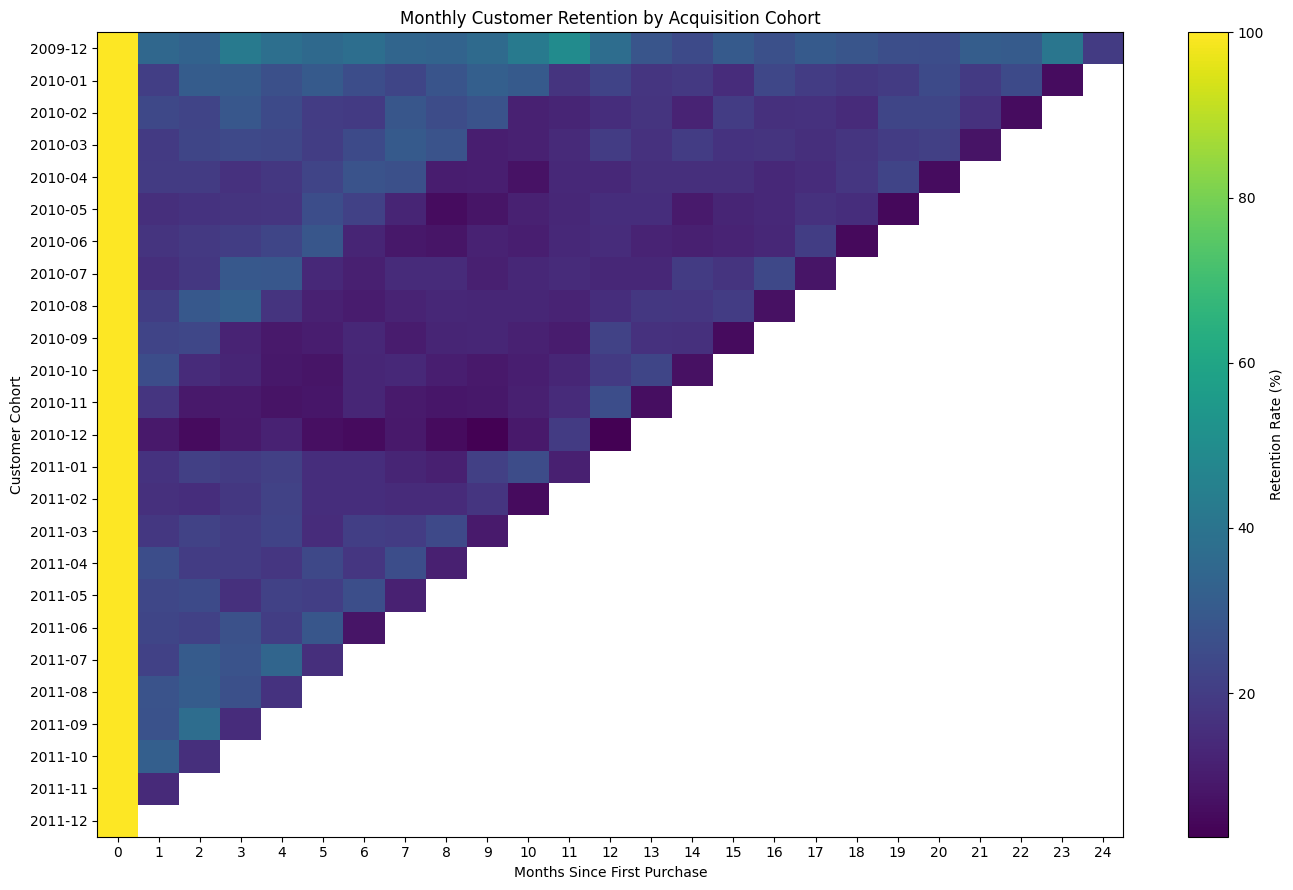

In [17]:
retention_pct = (
    retention_matrix * 100
).round(1)

fig, ax = plt.subplots(
    figsize=(14, 9)
)

image = ax.imshow(
    retention_pct.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(retention_pct.columns))
)

ax.set_xticklabels(
    retention_pct.columns
)

ax.set_yticks(
    range(len(retention_pct.index))
)

ax.set_yticklabels(
    retention_pct.index.astype(str)
)

ax.set_xlabel(
    "Months Since First Purchase"
)

ax.set_ylabel(
    "Customer Cohort"
)

ax.set_title(
    "Monthly Customer Retention by Acquisition Cohort"
)

plt.colorbar(
    image,
    label="Retention Rate (%)"
)

plt.tight_layout()

plt.show()

In [18]:
retention_summary = pd.DataFrame({
    "Month": [
        "Month 1",
        "Month 3",
        "Month 6",
        "Month 12"
    ],

    "Average_Retention_Rate": [
        retention_matrix[1].mean(),
        retention_matrix[3].mean(),
        retention_matrix[6].mean(),
        retention_matrix[12].mean()
    ]
})
retention_summary[
    "Average_Retention_Rate"
] = (
    retention_summary[
        "Average_Retention_Rate"
    ] * 100
).round(2)

retention_summary

,Month,Average_Retention_Rate
0,Month 1,21.17
1,Month 3,21.62
2,Month 6,17.82
3,Month 12,18.24


In [19]:
retention_pct.to_csv(
    "/content/cohort_retention_matrix.csv"
)

retention_summary.to_csv(
    "/content/retention_summary.csv",
    index=False
)